In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\rarch\OneDrive\Desktop\Emotion_Project\Dataset
['.ipynb_checkpoints', 'Tess Dataset', 'Untitled.ipynb']


In [29]:
paths = []
emotions = []
texts = []

folder = "Tess Dataset/TESS Toronto emotional speech set data"

for emotion_folder in os.listdir(folder):

    emotion_path = os.path.join(folder, emotion_folder)

    # only emotion folders
    if not (
        emotion_folder.startswith("OAF")
        or emotion_folder.startswith("YAF")
    ):
        continue

    for file in os.listdir(emotion_path):

        file_path = os.path.join(emotion_path, file)

        # emotion label
        emotion = emotion_folder.split('_')[-1].lower()

        # combine surprise
        if emotion == "surprised":
            emotion = "pleasant"

        # spoken word extraction
        filename = file.replace(".wav", "")

        parts = filename.split('_')

        if len(parts) >= 2:
            word = parts[1].lower()
        else:
            word = "unknown"

        paths.append(file_path)
        emotions.append(emotion)
        texts.append(word)

In [30]:
df = pd.DataFrame()

df["file_path"] = paths
df["emotion"] = emotions
df["text"] = texts

print(df.shape)

print(df["emotion"].value_counts())

(2800, 3)
emotion
angry       400
disgust     400
fear        400
happy       400
neutral     400
sad         400
surprise    200
pleasant    200
Name: count, dtype: int64


In [31]:
df["emotion"] = df["emotion"].replace(
    "surprise",
    "pleasant"
)

In [32]:
print(df["emotion"].value_counts())

emotion
angry       400
disgust     400
fear        400
happy       400
neutral     400
pleasant    400
sad         400
Name: count, dtype: int64


In [33]:
def preprocess_audio(file):

    audio, sr = librosa.load(file, sr=16000)

    # remove silence
    audio, _ = librosa.effects.trim(audio)

    # normalize
    audio = audio / np.max(np.abs(audio))

    # fixed audio length
    max_len = 16000 * 3

    if len(audio) < max_len:

        audio = np.pad(
            audio,
            (0, max_len - len(audio))
        )

    else:
        audio = audio[:max_len]

    return audio

In [34]:
def extract_mfcc(file):

    audio = preprocess_audio(file)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=40
    )

    mfcc = mfcc.T

    # fixed shape
    if mfcc.shape[0] < 94:

        pad = 94 - mfcc.shape[0]

        mfcc = np.pad(
            mfcc,
            ((0, pad), (0, 0))
        )

    else:
        mfcc = mfcc[:94, :]

    return mfcc

In [35]:
sample = df["file_path"][0]

features = extract_mfcc(sample)

print(features.shape)

(94, 40)


In [36]:
X = []
y = []

for _, row in df.iterrows():

    feat = extract_mfcc(row["file_path"])

    X.append(feat)

    y.append(row["emotion"])

In [37]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2800, 94, 40)
(2800,)


In [38]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(set(y))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    Conv1D(
        64,
        3,
        activation='relu',
        input_shape=(94,40)
    )
)

model.add(MaxPooling1D(2))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(7, activation='softmax'))

C:\Users\rarch\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.1638 - loss: 1.9607 - val_accuracy: 0.1652 - val_loss: 1.8528
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2396 - loss: 1.8616 - val_accuracy: 0.4487 - val_loss: 1.6631
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.3812 - loss: 1.6512 - val_accuracy: 0.7009 - val_loss: 1.2658
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.5416 - loss: 1.3054 - val_accuracy: 0.8683 - val_loss: 0.9145
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6422 - loss: 1.0466 - val_accuracy: 0.9241 - val_loss: 0.6756
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6725 - loss: 0.9088 - val_accuracy: 0.9576 - val_loss: 0.3940
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6996 - loss: 0.7802 - val_accuracy: 0.9509 - val_loss: 0.3307
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8038 - loss: 0.5767 - val_accu

In [43]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

print("Speech Accuracy:", acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9908 - loss: 0.0518
Speech Accuracy: 0.9910714030265808


In [44]:
model.save("models/speech_model.h5")

In [45]:
texts = df["text"].values

print(texts[:10])

['back' 'bar' 'base' 'bath' 'bean' 'beg' 'bite' 'boat' 'bone' 'book']


In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

X_text = tokenizer.texts_to_sequences(texts)

X_text = pad_sequences(
    X_text,
    maxlen=5
)

print(X_text[:5])

print(X_text.shape)

[[0 0 0 0 1]
 [0 0 0 0 2]
 [0 0 0 0 3]
 [0 0 0 0 4]
 [0 0 0 0 5]]
(2800, 5)


In [47]:
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

vocab_size = len(tokenizer.word_index) + 1

print(vocab_size)

model_text = Sequential()

model_text.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=5
    )
)

model_text.add(LSTM(64))

model_text.add(Dense(64, activation='relu'))

model_text.add(Dense(7, activation='softmax'))

201


In [52]:
model_text.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
history_text = model_text.fit(
    X_t_train,
    y_t_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1257 - loss: 1.9471 - val_accuracy: 0.1429 - val_loss: 1.9462
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1384 - loss: 1.9460 - val_accuracy: 0.1429 - val_loss: 1.9468
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1510 - loss: 1.9462 - val_accuracy: 0.1362 - val_loss: 1.9491
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1610 - loss: 1.9441 - val_accuracy: 0.0826 - val_loss: 1.9503
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1510 - loss: 1.9450 - val_accuracy: 0.0558 - val_loss: 1.9645
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1504 - loss: 1.9392 - val_accuracy: 0.0469 - val_loss: 1.9665
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1848 - loss: 1.9303 - val_accuracy: 0.0335 - val_loss: 2.0077
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1949 - loss: 1.9131 - val_accurac

In [54]:
loss, acc = model_text.evaluate(
    X_t_test,
    y_t_test
)

print("Text Accuracy:", acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0098 - loss: 2.5113
Text Accuracy: 0.008928571827709675


In [55]:
model_text.save("models/text_model.h5")

In [56]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
speech_input = Input(shape=(94,40))

x1 = Conv1D(
    64,
    3,
    activation='relu'
)(speech_input)

x1 = MaxPooling1D(2)(x1)

x1 = LSTM(64)(x1)

In [57]:
text_input = Input(shape=(5,))

x2 = Embedding(
    input_dim=vocab_size,
    output_dim=64
)(text_input)

x2 = LSTM(32)(x2)

In [58]:
combined = Concatenate()([x1, x2])

z = Dense(64, activation='relu')(combined)

z = Dropout(0.3)(z)

output = Dense(
    7,
    activation='softmax'
)(z)

In [59]:
fusion_model = Model(
    inputs=[speech_input, text_input],
    outputs=output
)

In [60]:
fusion_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
fusion_model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 94, 40)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 92, 64)            │           7,744 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_2               │ (None, 46, 64)            │               0 │ conv1d_2[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 5, 64)             │          12,864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_4 (LSTM)                 │ (None, 64)                │          33,024 │ max_pooling1d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_5 (LSTM)                 │ (None, 32)                │          12,416 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 96)                │               0 │ lstm_4[0][0], lstm_5[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 64)                │           6,208 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 64)                │               0 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 7)                 │             455 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 72,711 (284.03 KB)

 Trainable params: 72,711 (284.03 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history_fusion = fusion_model.fit(
    [X_train, X_t_train],
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.2499 - loss: 1.8652 - val_accuracy: 0.6205 - val_loss: 1.2291
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6908 - loss: 1.0417 - val_accuracy: 0.8661 - val_loss: 0.5671
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8727 - loss: 0.5591 - val_accuracy: 0.8929 - val_loss: 0.3465
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9162 - loss: 0.3399 - val_accuracy: 0.9397 - val_loss: 0.2536
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9206 - loss: 0.2650 - val_accuracy: 0.9598 - val_loss: 0.1927
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9603 - loss: 0.1757 - val_accuracy: 0.9621 - val_loss: 0.1349
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9661 - loss: 0.1329 - val_accuracy: 0.9531 - val_loss: 0.1452
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9549 - loss: 0.1642 - val_acc

In [63]:
loss, acc = fusion_model.evaluate(
    [X_test, X_t_test],
    y_test
)

print("Fusion Accuracy:", acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9499 - loss: 0.1150
Fusion Accuracy: 0.9589285850524902


In [64]:
fusion_model.save("models/fusion_model.h5")

In [65]:
pred_fusion = fusion_model.predict(
    [X_test, X_t_test]
)

pred_fusion = pred_fusion.argmax(axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


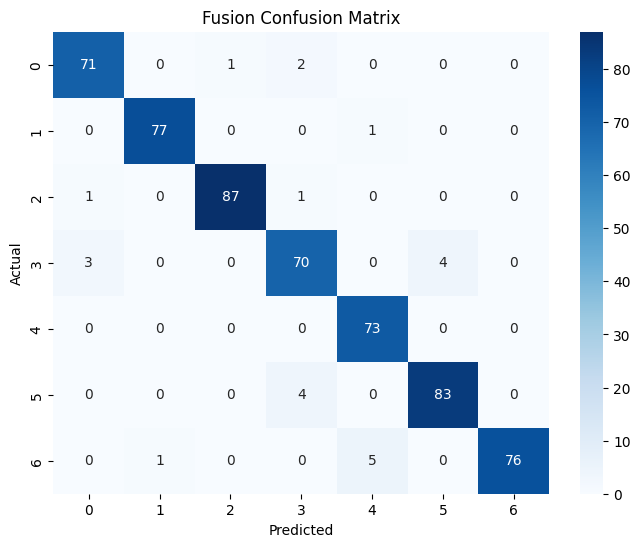

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred_fusion
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Fusion Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_fusion
    )
)

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        74
           1       0.99      0.99      0.99        78
           2       0.99      0.98      0.98        89
           3       0.91      0.91      0.91        77
           4       0.92      1.00      0.96        73
           5       0.95      0.95      0.95        87
           6       1.00      0.93      0.96        82

    accuracy                           0.96       560
   macro avg       0.96      0.96      0.96       560
weighted avg       0.96      0.96      0.96       560



In [68]:
fusion_model.save("models/fusion_model.h5")